In [1]:
import yfinance as yf
import pandas as pd
import os

# Create data directory if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Broaden our scope: Index + Major Stocks
tickers = ['^NSEI', 'RELIANCE.NS', 'HDFCBANK.NS', 'INFY.NS', 'TCS.NS']

print("Downloading market data...")
data = yf.download(tickers, period="2y", interval="1d")

# Save to CSV
data.to_csv('../data/nifty_raw_data.csv')
print("✅ Data for 5 tickers saved to /data/nifty_raw_data.csv")

[*********************100%***********************]  5 of 5 completed

✅ Data for 5 tickers saved to /data/nifty_raw_data.csv


In [2]:
import sys
import os
import pandas as pd
sys.path.append(os.path.abspath('..'))

from src.features import calculate_features
from src.anomaly_models import train_anomaly_detector

# 1. Load data (handling the MultiIndex from yfinance)
df = pd.read_csv('../data/nifty_raw_data.csv', index_col=0, header=[0,1])
all_tickers = df.columns.get_level_values(1).unique()

print(f"🕵️ Starting Market Scan on {len(all_tickers)} assets...\n")

for ticker in all_tickers:
    # Get individual stock data
    ticker_df = df.xs(ticker, axis=1, level=1).copy()
    
    # 2. Run AI Logic
    df_with_features = calculate_features(ticker_df)
    
    if len(df_with_features) > 30: # Ensure enough data for 20-day rolling
        final_df, model = train_anomaly_detector(df_with_features)
        
        # 3. Filter for alerts
        anomalies = final_df[final_df['anomaly_signal'] == -1]
        
        if not anomalies.empty:
            print(f"🚨 ALERT: {ticker}")
            print(f"   Found {len(anomalies)} suspicious days.")
            # Show the last alert's details
            last_alert = anomalies.tail(1)
            print(f"   Last Alert: {last_alert.index[0]} | Price: {last_alert['Close'].values[0]:.2f} | RSI: {last_alert['rsi'].values[0]:.1f}")
            print("-" * 50)
    else:
        print(f"Skipping {ticker}: Not enough data history.")

print("\n✅ Scan complete.")

🕵️ Starting Market Scan on 5 assets...

🚨 ALERT: HDFCBANK.NS
   Found 5 suspicious days.
   Last Alert: 2026-01-07 | Price: 949.05 | RSI: 30.9
--------------------------------------------------


c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_signal'] = model.fit_predict(X)
c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_signal'] = model.fit_predict(X)
c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

🚨 ALERT: INFY.NS
   Found 5 suspicious days.
   Last Alert: 2025-12-22 | Price: 1689.60 | RSI: 79.3
--------------------------------------------------
🚨 ALERT: RELIANCE.NS
   Found 5 suspicious days.
   Last Alert: 2026-01-06 | Price: 1507.60 | RSI: 41.7
--------------------------------------------------
🚨 ALERT: TCS.NS
   Found 5 suspicious days.
   Last Alert: 2025-07-11 | Price: 3184.96 | RSI: 29.8
--------------------------------------------------
🚨 ALERT: ^NSEI
   Found 5 suspicious days.
   Last Alert: 2025-02-28 | Price: 22124.70 | RSI: 2.0
--------------------------------------------------

✅ Scan complete.


c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_signal'] = model.fit_predict(X)
c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\features.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['volatility'] = df['Close'].pct_change().rolling(window=20).std()
c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

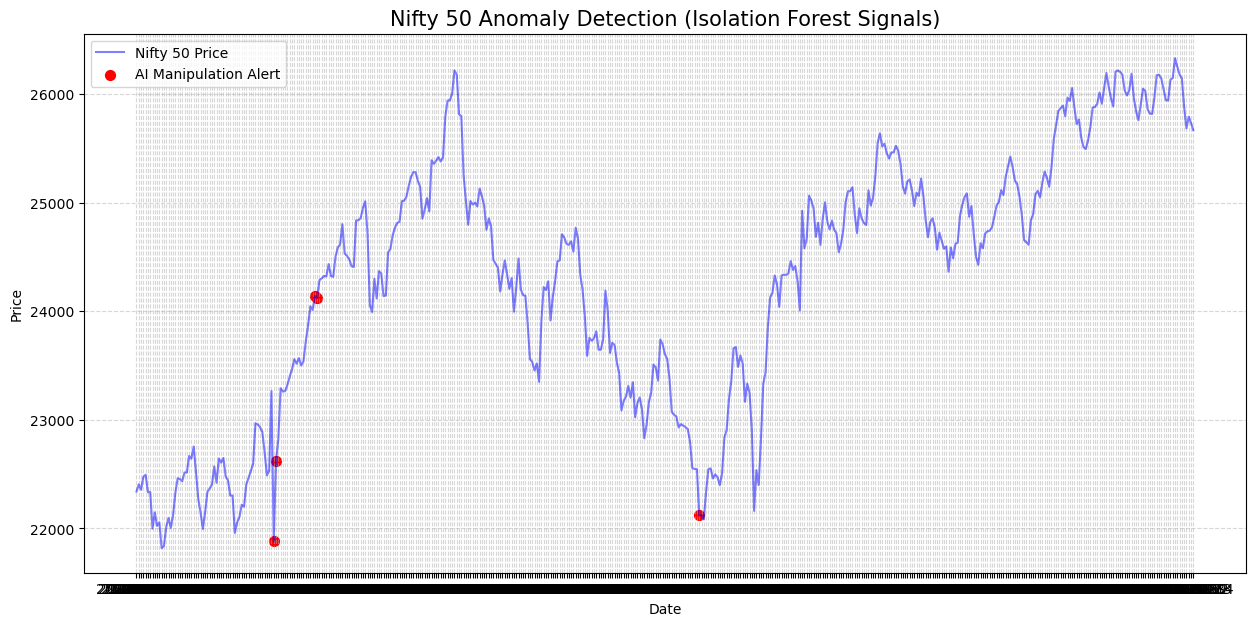

In [6]:
import matplotlib.pyplot as plt

# 1. Setup the plot
plt.figure(figsize=(15, 7))
plt.plot(final_df.index, final_df['Close'], label='Nifty 50 Price', color='blue', alpha=0.5)

# 2. Overlay the anomalies in RED
anomalies = final_df[final_df['anomaly_signal'] == -1]
plt.scatter(anomalies.index, anomalies['Close'], color='red', label='AI Manipulation Alert', s=50)

# 3. Formatting
plt.title('Nifty 50 Anomaly Detection (Isolation Forest Signals)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [7]:
import pandas as pd
from datetime import datetime

# 1. Create a container for all alerts
all_alerts = []

print("Generating Security Report...")

for ticker in all_tickers:
    ticker_df = df.xs(ticker, axis=1, level=1).copy()
    df_with_features = calculate_features(ticker_df)
    
    if len(df_with_features) > 20:
        final_df, model = train_anomaly_detector(df_with_features)
        
        # Filter for the most extreme alerts
        anomalies = final_df[final_df['anomaly_signal'] == -1].copy()
        
        if not anomalies.empty:
            anomalies['Ticker'] = ticker
            all_alerts.append(anomalies[['Ticker', 'Close', 'rsi', 'volume_ratio', 'z_score']])

# 2. Merge all alerts into one report
if all_alerts:
    report_df = pd.concat(all_alerts)
    
    # 3. Save to Excel/CSV for the Compliance Team
    filename = f"../data/Surveillance_Report_{datetime.now().strftime('%Y-%m-%d')}.csv"
    report_df.to_csv(filename)
    
    print(f"✅ SUCCESS: Report generated with {len(report_df)} total alerts.")
    print(f"📍 File saved at: {filename}")
    print("\nTop 5 Most Suspicious Movements:")
    print(report_df.sort_values(by='volume_ratio', ascending=False).head())
else:
    print("No anomalies detected today. Markets appear normal.")

Generating Security Report...


c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_signal'] = model.fit_predict(X)
c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_signal'] = model.fit_predict(X)
c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

✅ SUCCESS: Report generated with 25 total alerts.
📍 File saved at: ../data/Surveillance_Report_2026-02-02.csv

Top 5 Most Suspicious Movements:
Price            Ticker        Close        rsi  volume_ratio   z_score
Date                                                                   
2024-11-25  HDFCBANK.NS   880.892944  58.347692      8.861869  1.948750
2024-08-30  HDFCBANK.NS   807.534607  45.473120      8.049951  0.310811
2024-05-31       TCS.NS  3467.677979  32.139205      4.773494 -2.688909
2024-07-12       TCS.NS  3952.272217  74.312925      4.528625  2.598467
2024-08-29  RELIANCE.NS  1514.874756  77.953063      3.517831  1.594817


c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_signal'] = model.fit_predict(X)
c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\features.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['volatility'] = df['Close'].pct_change().rolling(window=20).std()
c:\Users\balam\OneDrive\nse-market-anomaly-detection\src\anomaly_models.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co